In [1]:
import pandas as pd
file_path = "cleaned_creditcard.csv"
df = pd.read_csv(file_path)
df_info = df.info()
df_head = df.head()
df_class_distribution = df["Class"].value_counts()

df_info, df_head, df_class_distribution

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 34 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Time           283726 non-null  float64
 1   V1             283726 non-null  float64
 2   V2             283726 non-null  float64
 3   V3             283726 non-null  float64
 4   V4             283726 non-null  float64
 5   V5             283726 non-null  float64
 6   V6             283726 non-null  float64
 7   V7             283726 non-null  float64
 8   V8             283726 non-null  float64
 9   V9             283726 non-null  float64
 10  V10            283726 non-null  float64
 11  V11            283726 non-null  float64
 12  V12            283726 non-null  float64
 13  V13            283726 non-null  float64
 14  V14            283726 non-null  float64
 15  V15            283726 non-null  float64
 16  V16            283726 non-null  float64
 17  V17            283726 non-nul

(None,
    Time        V1        V2        V3        V4        V5        V6        V7  \
 0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
 1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
 2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
 3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
 4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   
 
          V8        V9  ...       V24       V25       V26       V27       V28  \
 0  0.098698  0.363787  ...  0.066928  0.128539 -0.189115  0.133558 -0.021053   
 1  0.085102 -0.255425  ... -0.339846  0.167170  0.125895 -0.008983  0.014724   
 2  0.247676 -1.514654  ... -0.689281 -0.327642 -0.139097 -0.055353 -0.059752   
 3  0.377436 -1.387024  ... -1.175575  0.647376 -0.221929  0.062723  0.061458   
 4 -0.270533  0.817739  ...  0.141267 -0.206010  0.502292  0.219422  0.215153   
 
    Amount 

In [5]:
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, roc_curve, RocCurveDisplay
from collections import Counter
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
rng = np.random.RandomState(RANDOM_SEED)

file_path = "cleaned_creditcard.csv"
df = pd.read_csv(file_path)

if 'Class' not in df.columns:
    raise ValueError("Dataset must have a 'Class' column indicating fraud (1) or non-fraud (0).")

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

X_train_resampled = pd.DataFrame(X_train_resampled, columns=X.columns)

print("Class distribution AFTER SMOTE:", Counter(y_train_resampled))

fraud_indices = np.where(y_train_resampled == 1)[0] 

amount_col = 'Amount'
if amount_col in X_train_resampled.columns:
    noise = np.random.uniform(-0.05, 0.05, size=len(fraud_indices)) 
    X_train_resampled.loc[fraud_indices, amount_col] *= (1 + noise)

time_col = 'Time_Hours'
if time_col in X_train_resampled.columns:
    time_shift = np.random.randint(-2, 3, size=len(fraud_indices))
    X_train_resampled.loc[fraud_indices, time_col] += time_shift
    X_train_resampled[time_col] = X_train_resampled[time_col].clip(lower=0, upper=24) 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test) 

print("Mean of first few scaled features:", np.mean(X_train_scaled, axis=0))
print("Standard deviation of first few scaled features:", np.std(X_train_scaled, axis=0)[:5])

Class distribution AFTER SMOTE: Counter({0: 226602, 1: 226602})
Mean of first few scaled features: [-9.36929813e-17 -2.80953518e-17  1.77602760e-16  9.43201097e-17
  3.51191898e-17  2.70919464e-17  8.07741365e-17 -3.31123789e-17
 -7.52554067e-18  1.58538057e-16  4.31464331e-17  1.58538057e-16
 -1.53019327e-16 -1.37654681e-17  2.40817301e-16 -9.53235151e-18
  8.02724338e-18 -1.71582327e-16 -5.01702711e-18  2.20749193e-17
  1.00340542e-17 -1.31696962e-17 -1.81867233e-17 -5.80093760e-18
 -2.28274734e-17  9.15607448e-18 -1.42985273e-17 -3.01021627e-18
 -1.64934766e-17 -1.15705188e-16  1.42044580e-17 -1.01193437e-15
 -4.18169210e-16]
Standard deviation of first few scaled features: [1. 1. 1. 1. 1.]


# Logistic Regression

In [7]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train_resampled)
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]
print("\nLogistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_log):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_log):.4f}")


Logistic Regression Performance:
Accuracy: 0.9876
Precision: 0.1052
Recall: 0.8526
F1-score: 0.1873
AUC-ROC: 0.9648


In [9]:
import time

C_values = [0.01, 0.1, 1, 10, 100]

results = []

for c in C_values:
    log_reg = LogisticRegression(C=c, random_state=42, max_iter=1000)
    log_reg.fit(X_train_scaled, y_train_resampled)


    start_train = time.time()
    log_reg.fit(X_train_scaled, y_train_resampled)
    end_train = time.time()

    y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    thresholds = np.append(thresholds, 1)

    best_threshold = 0.5  # default
    for p, t in zip(precision, thresholds):
        if p >= 0.7:
            best_threshold = t
            break

    y_pred_adjusted = (y_prob >= best_threshold).astype(int)

    acc = accuracy_score(y_test, y_pred_adjusted)
    prec = precision_score(y_test, y_pred_adjusted)
    rec = recall_score(y_test, y_pred_adjusted)
    f1 = f1_score(y_test, y_pred_adjusted)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        'C': c,
        'Threshold': best_threshold,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'Accuracy': acc,
        'AUC-ROC': auc,
        'Train Time (s)': end_train - start_train
    })

results_df = pd.DataFrame(results)

print(results_df)

best_row = results_df.loc[results_df['AUC-ROC'].idxmax()]
best_c = best_row['C']

print(f"Best C based on AUC-ROC: {best_c}")
print(best_row)

        C  Threshold  Precision    Recall  F1-score  Accuracy   AUC-ROC  \
0    0.01   0.977075   0.700935  0.789474  0.742574  0.999084  0.967328   
1    0.10   0.984962   0.700935  0.789474  0.742574  0.999084  0.964951   
2    1.00   0.988645   0.700935  0.789474  0.742574  0.999084  0.964847   
3   10.00   0.989652   0.700935  0.789474  0.742574  0.999084  0.965153   
4  100.00   0.989640   0.700935  0.789474  0.742574  0.999084  0.965200   

   Train Time (s)  
0        3.121528  
1        6.206437  
2       10.219601  
3       13.561371  
4       11.831568  
Best C based on AUC-ROC: 0.01
C                 0.010000
Threshold         0.977075
Precision         0.700935
Recall            0.789474
F1-score          0.742574
Accuracy          0.999084
AUC-ROC           0.967328
Train Time (s)    3.121528
Name: 0, dtype: float64


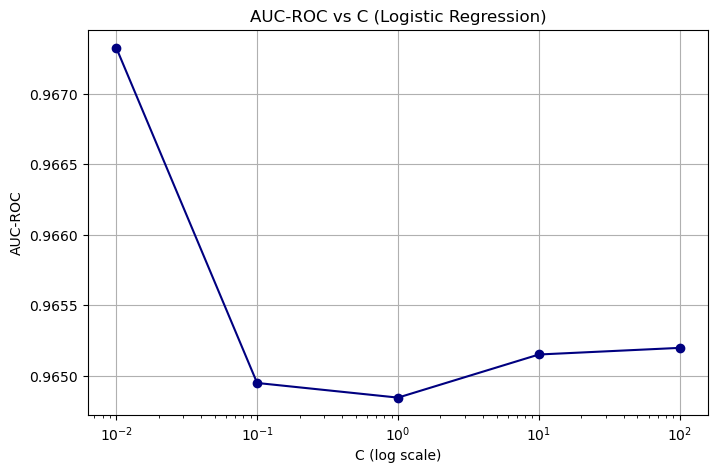

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Line Plot: AUC-ROC vs C (log scale)
plt.figure(figsize=(8,5))
plt.plot(results_df['C'], results_df['AUC-ROC'], marker='o', linestyle='-', color='navy')
plt.xscale('log')
plt.title('AUC-ROC vs C (Logistic Regression)')
plt.xlabel('C (log scale)')
plt.ylabel('AUC-ROC')
plt.grid(True)
plt.show()

Top 10 features by absolute coefficient:


,feature,coefficient,importance
0,V14,-4.958311,4.958311
1,V12,-4.259925,4.259925
2,V10,-2.708664,2.708664
3,V17,-2.503716,2.503716
4,V4,2.502222,2.502222
5,V8,-1.612144,1.612144
6,V1,1.465058,1.465058
7,V11,1.210630,1.210630
8,V5,1.143947,1.143947
9,V16,-1.090354,1.090354


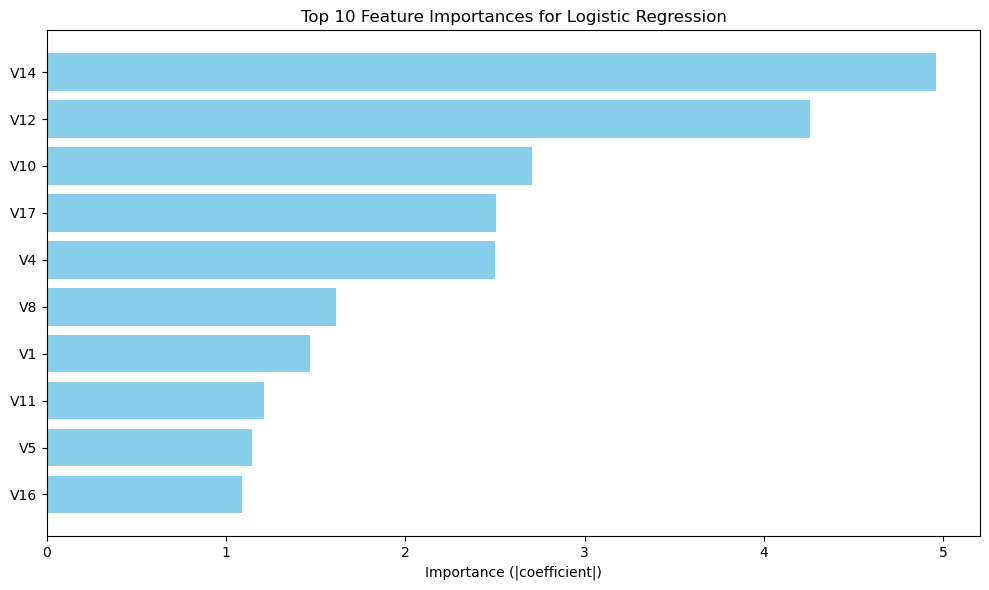

In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Retrain the best Logistic Regression on the full resampled training set
best_row = results_df.loc[results_df['AUC-ROC'].idxmax()]
best_c = best_row['C']

best_model = LogisticRegression(C=best_c, random_state=42, max_iter=1000)
best_model.fit(X_train_scaled, y_train_resampled)

# Extract feature names and coefficients
feature_names = X_train.columns.tolist()           # e.g. ['v1', 'v2', ..., 'v28']
coefficients  = best_model.coef_.flatten()         # shape (n_features,)

# Compute absolute importance
importance = np.abs(coefficients)

# Build a DataFrame of importances
feat_imp_df = pd.DataFrame({
    'feature':     feature_names,
    'coefficient': coefficients,
    'importance':  importance
})

# Sort by importance descending
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

# Display top 10 features
print("Top 10 features by absolute coefficient:")
display(feat_imp_df.head(10))

# Plot the top 10 feature importances
plt.figure(figsize=(10, 6))
plt.barh(
    feat_imp_df['feature'].head(10)[::-1],
    feat_imp_df['importance'].head(10)[::-1],
    color='skyblue'
)
plt.xlabel('Importance (|coefficient|)')
plt.title('Top 10 Feature Importances for Logistic Regression')
plt.tight_layout()
plt.show()

# Decision Tree

##从这里开始

In [64]:
# === 第一步 ===

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    precision_recall_curve, roc_curve
)
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings('ignore')

# 固定随机种子
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# 读数据
file_path = "cleaned_creditcard.csv"
df = pd.read_csv(file_path)

# 检查 Time_Hours 是否存在
if 'Time_Hours' not in df.columns:
    raise ValueError("Time_Hours 列缺失，请确认数据预处理正确！")

# 分出特征与标签
X = df.drop(columns=['Class'])
y = df['Class']

print(df.info())
print(df.head())
print(df['Class'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 34 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Time           283726 non-null  float64
 1   V1             283726 non-null  float64
 2   V2             283726 non-null  float64
 3   V3             283726 non-null  float64
 4   V4             283726 non-null  float64
 5   V5             283726 non-null  float64
 6   V6             283726 non-null  float64
 7   V7             283726 non-null  float64
 8   V8             283726 non-null  float64
 9   V9             283726 non-null  float64
 10  V10            283726 non-null  float64
 11  V11            283726 non-null  float64
 12  V12            283726 non-null  float64
 13  V13            283726 non-null  float64
 14  V14            283726 non-null  float64
 15  V15            283726 non-null  float64
 16  V16            283726 non-null  float64
 17  V17            283726 non-nul

In [66]:
# === 第二步 ===

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# SMOTE前类别分布
print("\nClass distribution BEFORE SMOTE:")
print(pd.Series(y_train).value_counts())
print("Before SMOTE - Fraud ratio:", y_train.value_counts()[1] / y_train.value_counts().sum())

# baseline：SMOTE前直接训练（标准化）
scaler_before = StandardScaler()
X_train_scaled_before = scaler_before.fit_transform(X_train)
X_test_scaled_before = scaler_before.transform(X_test)

baseline_dt_before = DecisionTreeClassifier(random_state=RANDOM_SEED, class_weight="balanced")

import time
start_train_before = time.time()
baseline_dt_before.fit(X_train_scaled_before, y_train)
end_train_before = time.time()

y_pred_before = baseline_dt_before.predict(X_test_scaled_before)
y_prob_before = baseline_dt_before.predict_proba(X_test_scaled_before)[:, 1]

baseline_before_results = {
    'Precision': precision_score(y_test, y_pred_before),
    'Recall': recall_score(y_test, y_pred_before),
    'F1-score': f1_score(y_test, y_pred_before),
    'AUC-ROC': roc_auc_score(y_test, y_prob_before),
    'Train Time (s)': end_train_before - start_train_before
}

print("\n=== Baseline BEFORE SMOTE ===")
for k, v in baseline_before_results.items():
    print(f"{k}: {v:.4f}")

# 做SMOTE过采样
smote = SMOTE(random_state=RANDOM_SEED)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
X_train_resampled = pd.DataFrame(X_train_resampled, columns=X.columns)

# 对SMOTE后的欺诈样本添加扰动
fraud_indices = np.where(y_train_resampled == 1)[0]

amount_col = 'Amount'
if amount_col in X_train_resampled.columns:
    noise = np.random.uniform(-0.05, 0.05, size=len(fraud_indices))
    X_train_resampled.loc[fraud_indices, amount_col] *= (1 + noise)

time_col = 'Time_Hours'
if time_col in X_train_resampled.columns:
    time_shift = np.random.randint(-2, 3, size=len(fraud_indices))
    X_train_resampled.loc[fraud_indices, time_col] += time_shift
    X_train_resampled[time_col] = X_train_resampled[time_col].clip(lower=0, upper=24)

# SMOTE后类别分布
print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print("After SMOTE - Fraud ratio:", y_train_resampled.value_counts()[1] / y_train_resampled.value_counts().sum())

# baseline：SMOTE后训练（标准化）
scaler_after = StandardScaler()
X_train_scaled_after = scaler_after.fit_transform(X_train_resampled)
X_test_scaled_after = scaler_after.transform(X_test)

baseline_dt_after = DecisionTreeClassifier(random_state=RANDOM_SEED, class_weight="balanced")

start_train_after = time.time()
baseline_dt_after.fit(X_train_scaled_after, y_train_resampled)
end_train_after = time.time()

y_pred_after = baseline_dt_after.predict(X_test_scaled_after)
y_prob_after = baseline_dt_after.predict_proba(X_test_scaled_after)[:, 1]

baseline_after_results = {
    'Precision': precision_score(y_test, y_pred_after),
    'Recall': recall_score(y_test, y_pred_after),
    'F1-score': f1_score(y_test, y_pred_after),
    'AUC-ROC': roc_auc_score(y_test, y_prob_after),
    'Train Time (s)': end_train_after - start_train_after
}

print("\n=== Baseline AFTER SMOTE ===")
for k, v in baseline_after_results.items():
    print(f"{k}: {v:.4f}")

# 结果对比表
comparison_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-score', 'AUC-ROC', 'Train Time (s)'],
    'Before SMOTE': [
        baseline_before_results['Precision'],
        baseline_before_results['Recall'],
        baseline_before_results['F1-score'],
        baseline_before_results['AUC-ROC'],
        baseline_before_results['Train Time (s)'],
    ],
    'After SMOTE': [
        baseline_after_results['Precision'],
        baseline_after_results['Recall'],
        baseline_after_results['F1-score'],
        baseline_after_results['AUC-ROC'],
        baseline_after_results['Train Time (s)'],
    ]
})

print("\n=== SMOTE前后训练模型结果对比 ===")
display(comparison_df)



Class distribution BEFORE SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64
Before SMOTE - Fraud ratio: 0.0016653449643140364

=== Baseline BEFORE SMOTE ===
Precision: 0.7195
Recall: 0.6211
F1-score: 0.6667
AUC-ROC: 0.8103
Train Time (s): 22.6637

Class distribution AFTER SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64
After SMOTE - Fraud ratio: 0.5

=== Baseline AFTER SMOTE ===
Precision: 0.4551
Recall: 0.7474
F1-score: 0.5657
AUC-ROC: 0.8729
Train Time (s): 115.3319

=== SMOTE前后训练模型结果对比 ===


,Metric,Before SMOTE,After SMOTE
0,Precision,0.719512,0.455128
1,Recall,0.621053,0.747368
2,F1-score,0.666667,0.565737
3,AUC-ROC,0.810323,0.872934
4,Train Time (s),22.663668,115.331878


In [ ]:
# === 第三步 ===

max_depth_values = [3, 5, 7, 9, 12, 15]
results = []

for depth in max_depth_values:
    dt_model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=RANDOM_SEED,
        class_weight="balanced"
    )
    
    start_train = time.time()
    dt_model.fit(X_train_scaled_after, y_train_resampled)
    end_train = time.time()

    y_prob = dt_model.predict_proba(X_test_scaled_after)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    thresholds = np.append(thresholds, 1)

    best_threshold = 0.5
    for p, t in zip(precision, thresholds):
        if p >= 0.7:
            best_threshold = t
            break

    y_pred_adjusted = (y_prob >= best_threshold).astype(int)

    acc = accuracy_score(y_test, y_pred_adjusted)
    prec = precision_score(y_test, y_pred_adjusted)
    rec = recall_score(y_test, y_pred_adjusted)
    f1 = f1_score(y_test, y_pred_adjusted)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Max Depth': depth,
        'Threshold': best_threshold,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'Accuracy': acc,
        'AUC-ROC': auc,
        'Train Time (s)': end_train - start_train
    })

results_df = pd.DataFrame(results)

print("\nParameter tuning results:")
print(results_df)

# 选最优
best_row = results_df.loc[results_df['AUC-ROC'].idxmax()]
best_depth = int(best_row['Max Depth'])

print(f"\nBest max_depth based on AUC-ROC: {best_depth}")
print(best_row)


In [ ]:
# === 第四步 ===

best_dt_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=RANDOM_SEED,
    class_weight="balanced"
)
best_dt_model.fit(X_train_scaled_after, y_train_resampled)

# 特征重要性
feature_names = X.columns.tolist()
importances = best_dt_model.feature_importances_

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'raw_importance': importances,
    'importance': np.abs(importances)
})

feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

print("\nTop 10 important features (Decision Tree):")
display(feat_imp_df.head(10))

# Top10特征图
plt.figure(figsize=(10, 6))
plt.barh(
    feat_imp_df['feature'].head(10)[::-1],
    feat_imp_df['importance'].head(10)[::-1],
    color='lightgreen'
)
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances for Decision Tree')
plt.tight_layout()
plt.show()

# PR曲线
y_prob_best = best_dt_model.predict_proba(X_test_scaled_after)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_prob_best)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label="Decision Tree (PR Curve)")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

# ROC曲线
fpr, tpr, _ = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label="Decision Tree (ROC Curve)")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()
